In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import pyarrow 
import pyarrow.parquet
from matplotlib import pyplot
import time

In [24]:
df = pd.read_csv("results.csv")

In [25]:
summary = df.groupby(["drift_type", "window"]).agg(
    tp_regular    = ("tp_regular",    "mean"),
    fp_regular    = ("fp_regular",    "mean"),
    fn_regular    = ("fn_regular",    "mean"),
    delay_regular = ("delay_regular", "mean"),

    tp_irregular    = ("tp_irregular",    "mean"),
    fp_irregular    = ("fp_irregular",    "mean"),
    fn_irregular    = ("fn_irregular",    "mean"),
    delay_irregular = ("delay_irregular", "mean"),
).round(2)

print(summary.to_string())

                   tp_regular  fp_regular  fn_regular  delay_regular  tp_irregular  fp_irregular  fn_irregular  delay_irregular
drift_type window                                                                                                              
1          168           0.75        0.50        0.25         154.20          1.00          3.00          0.00          2358.40
           720           0.60        7.62        0.40        2527.62          0.95         11.45          0.05          1362.89
           2160          0.83       17.22        0.17        2083.48          0.75         18.78          0.25           540.53
2          168           0.75        0.00        0.25        7963.80          1.00          3.00          0.00          6080.80
           720           0.70        4.55        0.30       11529.79          0.95          5.90          0.05          5403.74
           2160          0.82        1.02        0.18        8324.04          0.80          3.37        

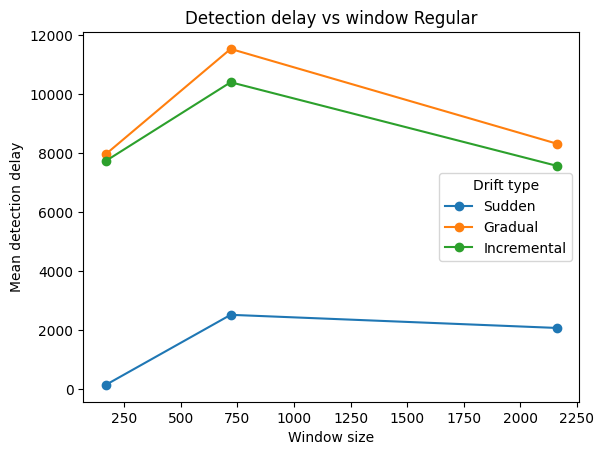

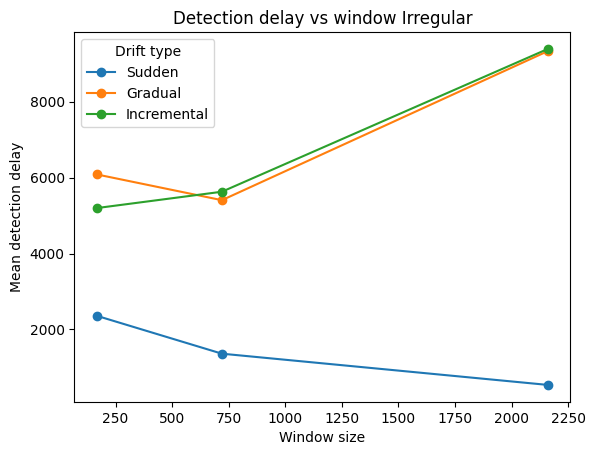

In [26]:
drift_labels = {1: "Sudden", 2: "Gradual", 3: "Incremental"}

for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary.groupby("drift_type"):
        windows = group.index.get_level_values("window")
        plt.plot(windows, group[f"delay_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"Detection delay vs window {dataset}")
    plt.xlabel("Window size")
    plt.ylabel("Mean detection delay")
    plt.legend(title="Drift type")
    plt.show()

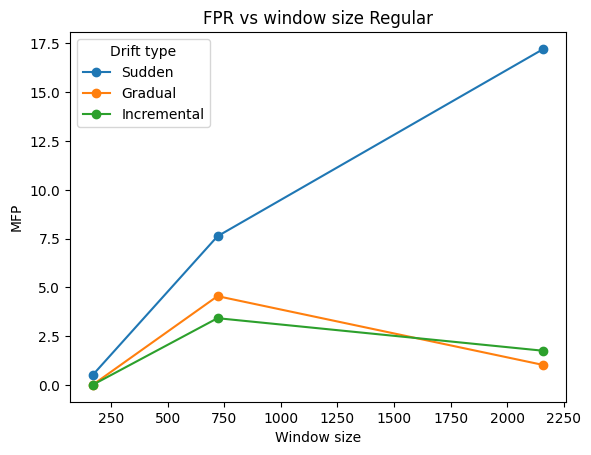

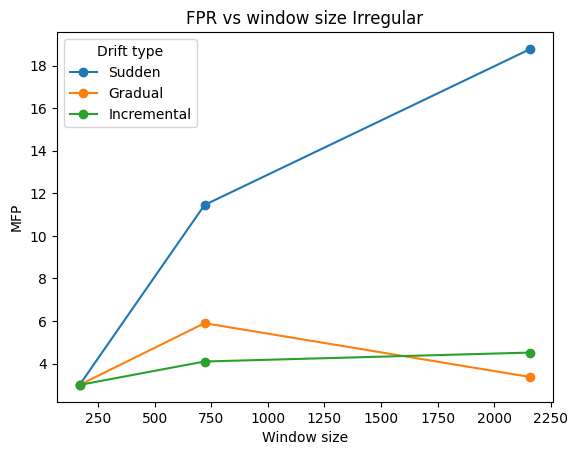

In [27]:
for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary.groupby("drift_type"):
        windows = group.index.get_level_values("window")
        plt.plot(windows, group[f"fp_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"FPR vs window size {dataset}")
    plt.xlabel("Window size")
    plt.ylabel("MFP")
    plt.legend(title="Drift type")
    plt.show()

In [28]:
summary_step = df.groupby(["drift_type", "step"]).agg(
    tp_regular      = ("tp_regular",    "mean"),
    fp_regular      = ("fp_regular",    "mean"),
    fn_regular      = ("fn_regular",    "mean"),
    delay_regular   = ("delay_regular", "mean"),
    tp_irregular    = ("tp_irregular",    "mean"),
    fp_irregular    = ("fp_irregular",    "mean"),
    fn_irregular    = ("fn_irregular",    "mean"),
    delay_irregular = ("delay_irregular", "mean"),
).round(2)

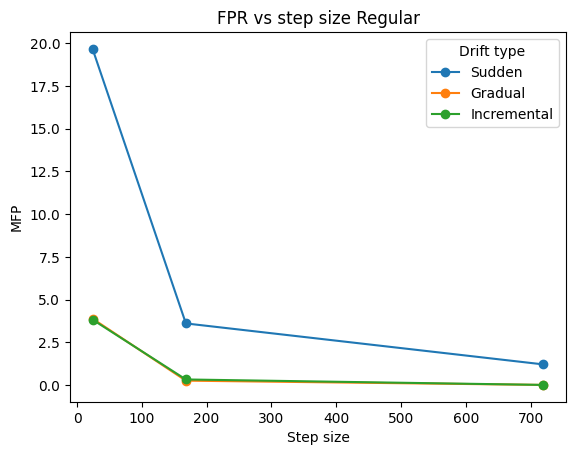

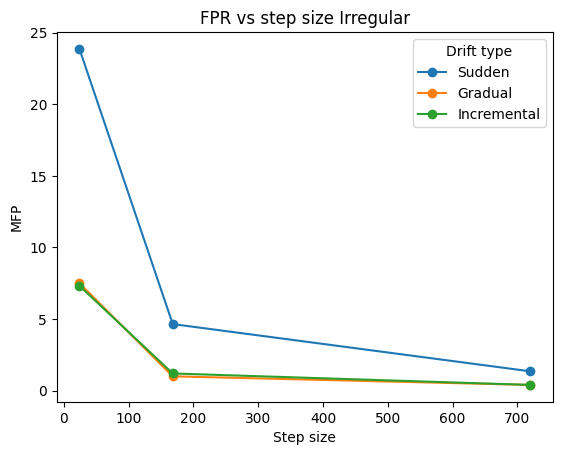

In [29]:
for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary_step.groupby("drift_type"):
        steps = group.index.get_level_values("step")
        plt.plot(steps, group[f"fp_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"FPR vs step size {dataset}")
    plt.xlabel("Step size")
    plt.ylabel("MFP")
    plt.legend(title="Drift type")
    plt.show()